In [2]:
# --- CELL 1: IMPORTS & SETTINGS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

# Scikit-Learn Ecosystem
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA, FastICA
from sklearn.manifold import TSNE, SpectralEmbedding, Isomap, LocallyLinearEmbedding
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans

# UMAP (Cek jika terinstall)
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("Warning: 'umap-learn' not installed. UMAP analysis will be skipped.")

# Konfigurasi Visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
warnings.filterwarnings('ignore')

# Helper untuk menampilkan semua kolom pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Libraries Loaded & Configured.")

✅ Libraries Loaded & Configured.


In [20]:
# --- CELL 2: MCU COMPREHENSIVE ANALYZER CLASS (UPDATED) ---

class MCUAnalyzer:
    def __init__(self, file_path, delimiter=','):
        self.file_path = Path(file_path)
        self.df = None
        self.df_scaled = None
        self.outliers_mask = None
        self.delimiter = delimiter
        
    def load_data(self):
        """Memuat data dan melakukan cleaning dasar."""
        if not self.file_path.exists():
            print(f"❌ File not found at: {self.file_path}")
            return False
        
        self.df = pd.read_csv(self.file_path, delimiter=self.delimiter)
        print(f"✅ Data Loaded. Shape: {self.df.shape}")
        
        # Drop kolom ID/Badge
        if 'BADGE' in self.df.columns:
            self.df = self.df.drop(columns=['BADGE'])
        
        # Pastikan hanya numerik
        self.df = self.df.select_dtypes(include=[np.number])
        return True

    def _scale_data(self):
        """Helper: RobustScaler untuk menangani outlier."""
        scaler = RobustScaler()
        self.df_scaled = pd.DataFrame(scaler.fit_transform(self.df.fillna(self.df.median())), 
                                      columns=self.df.columns)
        return self.df_scaled

    # --- SECTION I & II: BASIC CHECKS (Diringkas untuk hemat tempat) ---
    def check_data_quality(self):
        print("\n--- I. DATA QUALITY CHECK ---")
        print(f"🔎 Duplicates: {self.df.duplicated().sum()}")
        if self.df.duplicated().sum() > 0: self.df.drop_duplicates(inplace=True)
        
        iso = IsolationForest(contamination=0.05, random_state=42)
        self.outliers_mask = iso.fit_predict(self.df.fillna(self.df.median())) == -1
        print(f"   Outliers detected (IsolationForest): {sum(self.outliers_mask)}")

    def analyze_features(self):
        print("\n--- II. FEATURE ANALYSIS ---")
        # Menggunakan Spearman untuk menangkap hubungan non-linear
        plt.figure(figsize=(10, 8))
        corr = self.df.corr(method='spearman')
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True, cbar_kws={"shrink": .5})
        plt.title("Spearman Correlation Heatmap")
        plt.show()

    # --- SECTION III: DIMENSIONAL ANALYSIS (Updated max_iter) ---
    def analyze_dimensions(self):
        print("\n--- III. DIMENSIONAL BEHAVIOR ANALYSIS ---")
        X = self._scale_data()
        
        fig, axes = plt.subplots(2, 2, figsize=(18, 15))
        
        # 6. PCA
        pca = PCA(n_components=2)
        pca_res = pca.fit_transform(X)
        sns.scatterplot(x=pca_res[:,0], y=pca_res[:,1], ax=axes[0,0], alpha=0.6)
        axes[0,0].set_title(f"PCA (Var: {sum(pca.explained_variance_ratio_):.2f})")
        
        # 7. ICA (Updated: menggunakan max_iter)
        ica = FastICA(n_components=2, max_iter=1000, random_state=42)
        ica_res = ica.fit_transform(X)
        sns.scatterplot(x=ica_res[:,0], y=ica_res[:,1], ax=axes[0,1], alpha=0.6, color='orange')
        axes[0,1].set_title("ICA (Independent Components)")
        
        # 8. t-SNE (Note: sklearn TSNE uses n_iter, not max_iter. Keeping n_iter for compatibility)
        tsne = TSNE(n_components=2, perplexity=30, max_iter=2000, random_state=42)
        tsne_res = tsne.fit_transform(X)
        sns.scatterplot(x=tsne_res[:,0], y=tsne_res[:,1], ax=axes[1,0], alpha=0.6, color='green')
        axes[1,0].set_title("t-SNE (Local Manifold)")
        
        # 9. UMAP
        if HAS_UMAP:
            # UMAP uses n_epochs instead of max_iter/n_iter
            umap_mod = umap.UMAP(n_neighbors=15, min_dist=0.1, n_epochs=500, random_state=42)
            umap_res = umap_mod.fit_transform(X)
            sns.scatterplot(x=umap_res[:,0], y=umap_res[:,1], ax=axes[1,1], alpha=0.6, color='purple')
            axes[1,1].set_title("UMAP")
        
        plt.tight_layout()
        plt.show()

    # --- SECTION IV: SMART PAIRPLOT (NEW FEATURE) ---
    def analyze_key_features_pairplot(self, n_top=6):
        """
        Memilih fitur terbaik berdasarkan PCA Loadings dan membuat Pairplot.
        Ini membantu melihat separasi cluster pada fitur yang paling berpengaruh.
        """
        print(f"\n--- SMART FEATURE SELECTION & PAIRPLOT (Top {n_top} Features) ---")
        X = self._scale_data()
        
        # 1. Gunakan PCA untuk mencari fitur yang paling "membedakan" data
        pca = PCA(n_components=2)
        pca.fit(X)
        
        # Hitung magnitude loadings (seberapa kuat fitur menarik data ke PC1/PC2)
        loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=X.columns)
        loadings['importance'] = np.sqrt(loadings['PC1']**2 + loadings['PC2']**2)
        
        # Ambil Top N fitur dengan importance tertinggi
        top_features = loadings.sort_values('importance', ascending=False).head(n_top).index.tolist()
        print(f"🌟 Top Features detected for Clustering:\n{top_features}")
        
        # 2. Generate 'Hint Cluster' (K-Means Cepat) untuk pewarnaan (Hue)
        # Ini supaya pairplot tidak satu warna, kita bisa lihat potensi separasinya
        kmeans = KMeans(n_clusters=3, max_iter=1000, random_state=42, n_init=10)
        cluster_hint = kmeans.fit_predict(X[top_features])
        
        # 3. Buat DataFrame Subset untuk Plotting
        plot_df = self.df[top_features].copy()
        # Handle NaN untuk plotting
        plot_df = plot_df.fillna(plot_df.median())
        plot_df['Potential_Cluster'] = cluster_hint.astype(str) # String agar discrete color
        
        # 4. Render Pairplot
        print("🎨 Generating Pairplot... (This might take a moment)")
        g = sns.pairplot(plot_df, hue='Potential_Cluster', palette='viridis', corner=True, plot_kws={'alpha':0.6})
        g.fig.suptitle(f"Pairplot of Top {n_top} Clustering-Driving Features", y=1.02)
        plt.show()

    # --- SECTION V: CLUSTERABILITY (Fixed: Removed .values) ---
    def check_clusterability(self):
        print("\n--- IV. CLUSTERABILITY TESTING ---")
        X = self._scale_data().values
        
        # 10. Hopkins Statistic
        h_score = self._hopkins_statistic(X)
        print(f"🎲 Hopkins Statistic: {h_score:.4f} (Mendekati 0 = Clusterable, 0.5 = Random)")
        
        # 11. VAT
        if len(X) > 2000: X = X[np.random.choice(len(X), 2000, replace=False)]
        dist_matrix = squareform(pdist(X))
        link_matrix = linkage(dist_matrix, method='single')
        order = dendrogram(link_matrix, no_plot=True)['leaves']
        ordered_dist = dist_matrix[order, :][:, order]
        
        plt.figure(figsize=(6, 6))
        plt.imshow(ordered_dist, cmap='gray', aspect='auto')
        plt.title("VAT Image")
        plt.show()
        
        # --- HELPER: PCA RUNNER ---
    def run_pca(self, n_components=2, scale=True, return_model=False):
        """
        Helper untuk menjalankan PCA dengan parameter fleksibel.
        - scale=True: gunakan RobustScaler
        - return_model=True: balikin model PCA aslinya
        """
        print(f"\n⚙️ Running PCA (n_components={n_components})")

        X = self._scale_data() if scale else self.df.fillna(self.df.median())

        pca = PCA(n_components=n_components, random_state=42)
        components = pca.fit_transform(X)

        explained = pca.explained_variance_ratio_.sum()
        print(f"   ➤ Total Explained Variance: {explained:.4f}")

        if return_model:
            return components, pca
        return components
    
        # --- HELPER: UMAP RUNNER ---
    def run_umap(self, n_neighbors=15, min_dist=0.1, metric='euclidean', 
                 n_components=2, n_epochs=500, scale=True, return_model=False):
        """
        Helper untuk menjalankan UMAP dengan parameter custom.
        """
        if not HAS_UMAP:
            print("❌ UMAP tidak terinstall.")
            return None

        print(f"\n⚙️ Running UMAP:"
              f" n_neighbors={n_neighbors}, min_dist={min_dist}, metric={metric}")

        X = self._scale_data() if scale else self.df.fillna(self.df.median())

        reducer = umap.UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric=metric,
            n_components=n_components,
            n_epochs=n_epochs,
            random_state=42
        )

        embedding = reducer.fit_transform(X)

        if return_model:
            return embedding, reducer
        return embedding



    def _hopkins_statistic(self, X):
        d = X.shape[1]
        n = len(X)
        m = int(0.1 * n)
        nbrs = NearestNeighbors(n_neighbors=1).fit(X) # FIXED: Removed .values
        
        ujd = []
        wjd = []
        for j in range(0, m):
            u_dist, _ = nbrs.kneighbors(np.random.uniform(np.amin(X,axis=0),np.amax(X,axis=0),d).reshape(1, -1), 2, return_distance=True)
            ujd.append(u_dist[0][1])
            w_dist, _ = nbrs.kneighbors(X[np.random.randint(0, n)].reshape(1, -1), 2, return_distance=True)
            wjd.append(w_dist[0][1])
            
        H = sum(ujd) / (sum(ujd) + sum(wjd)) if (sum(ujd) + sum(wjd)) != 0 else 0
        return 0 if np.isnan(H) else H

✅ Data Loaded. Shape: (1887, 54)

--- I. DATA QUALITY CHECK ---
🔎 Duplicates: 0
   Outliers detected (IsolationForest): 95

--- III. DIMENSIONAL BEHAVIOR ANALYSIS ---


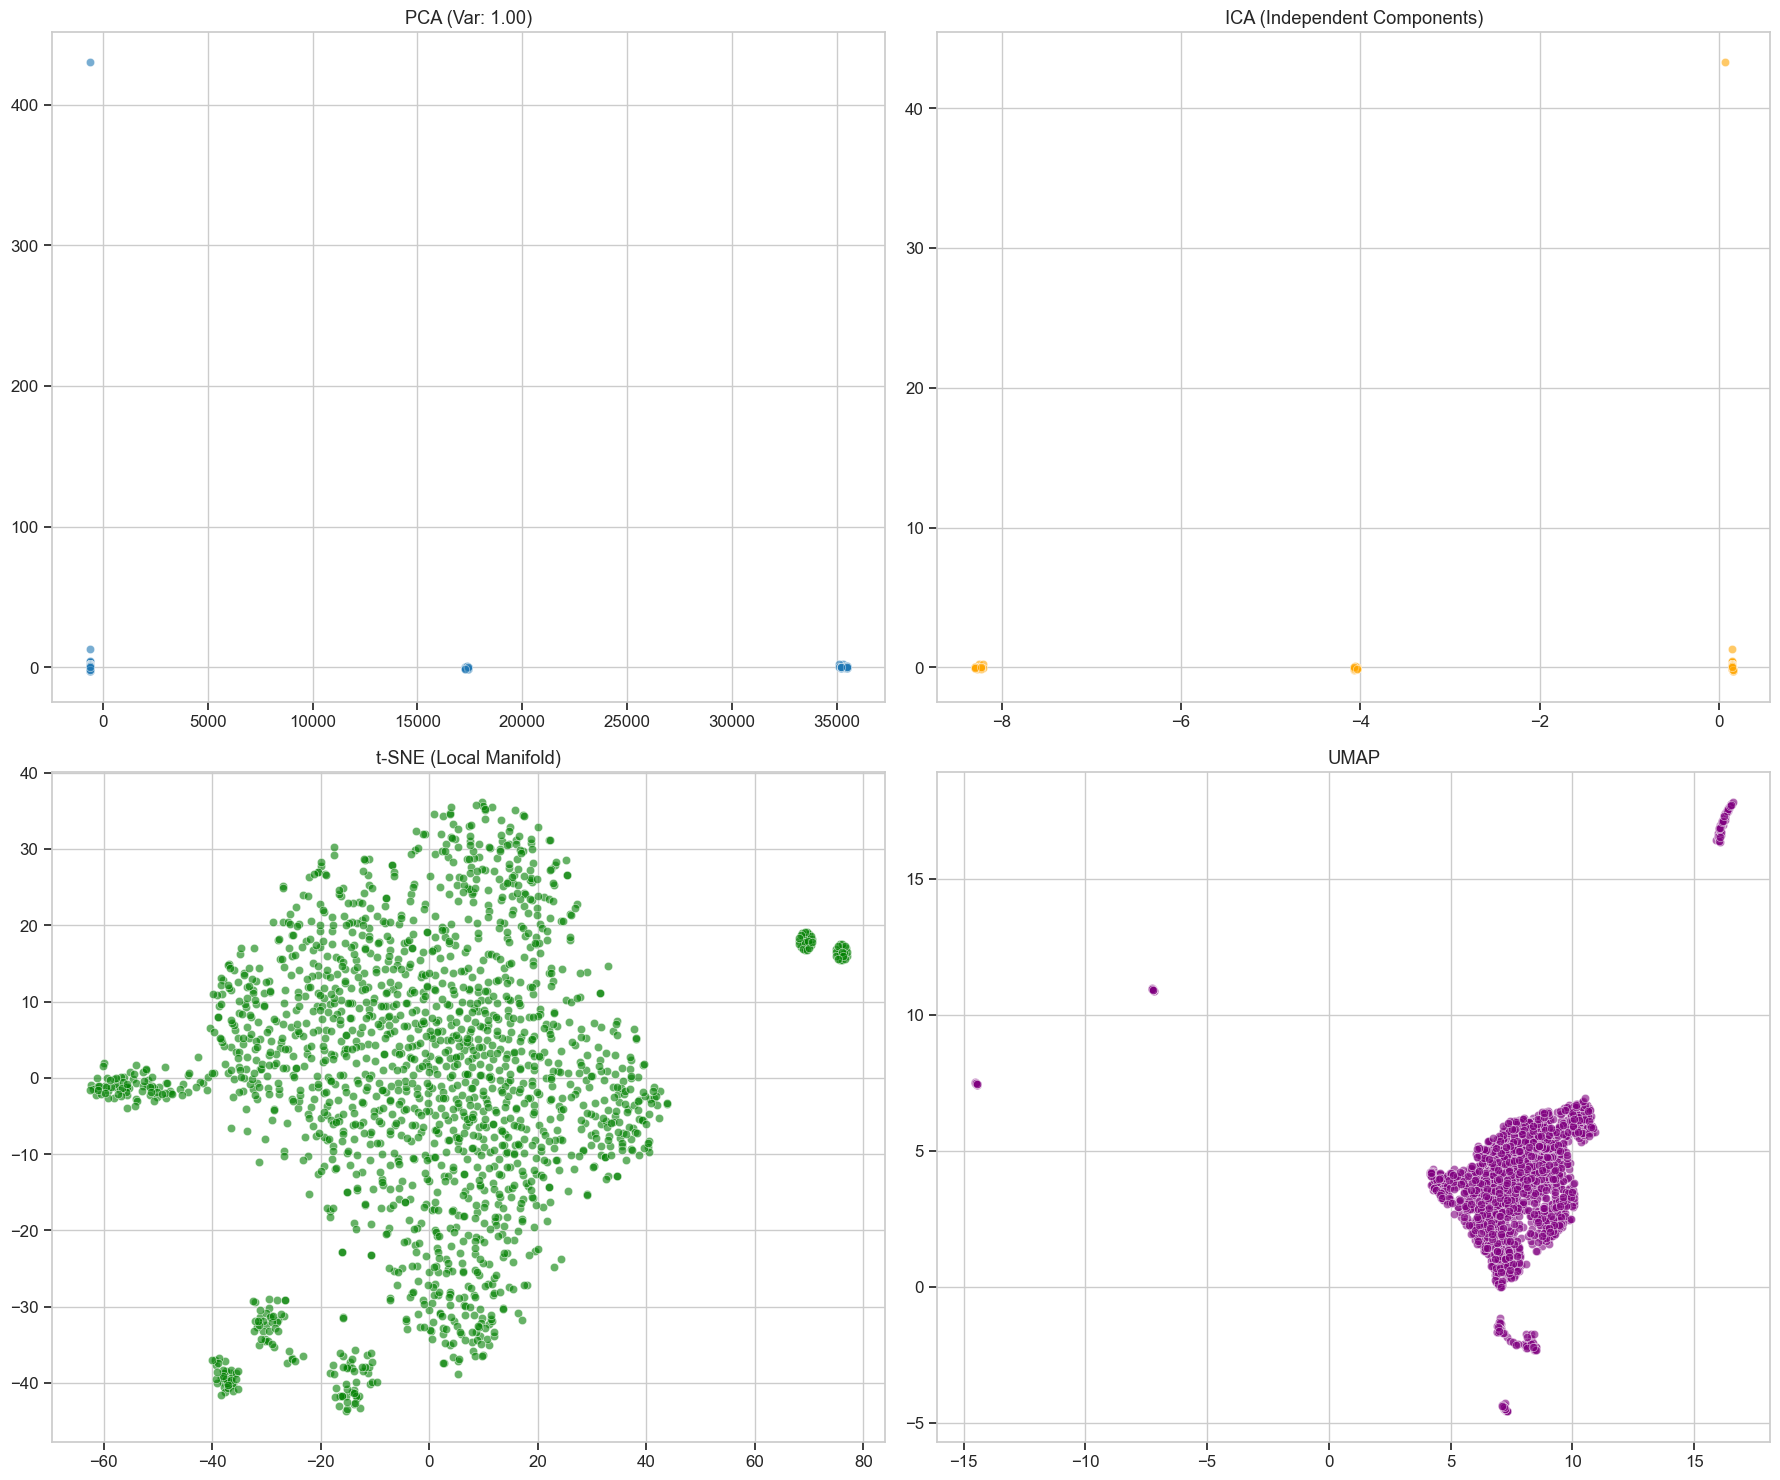


--- SMART FEATURE SELECTION & PAIRPLOT (Top 6 Features) ---
🌟 Top Features detected for Clustering:
['SUHU', 'NADI', 'PERNAPASAN', 'GULA_DARAH_2JAMPP', 'GULA_DARAH_PUASA', 'GAMMA_GT']
🎨 Generating Pairplot... (This might take a moment)


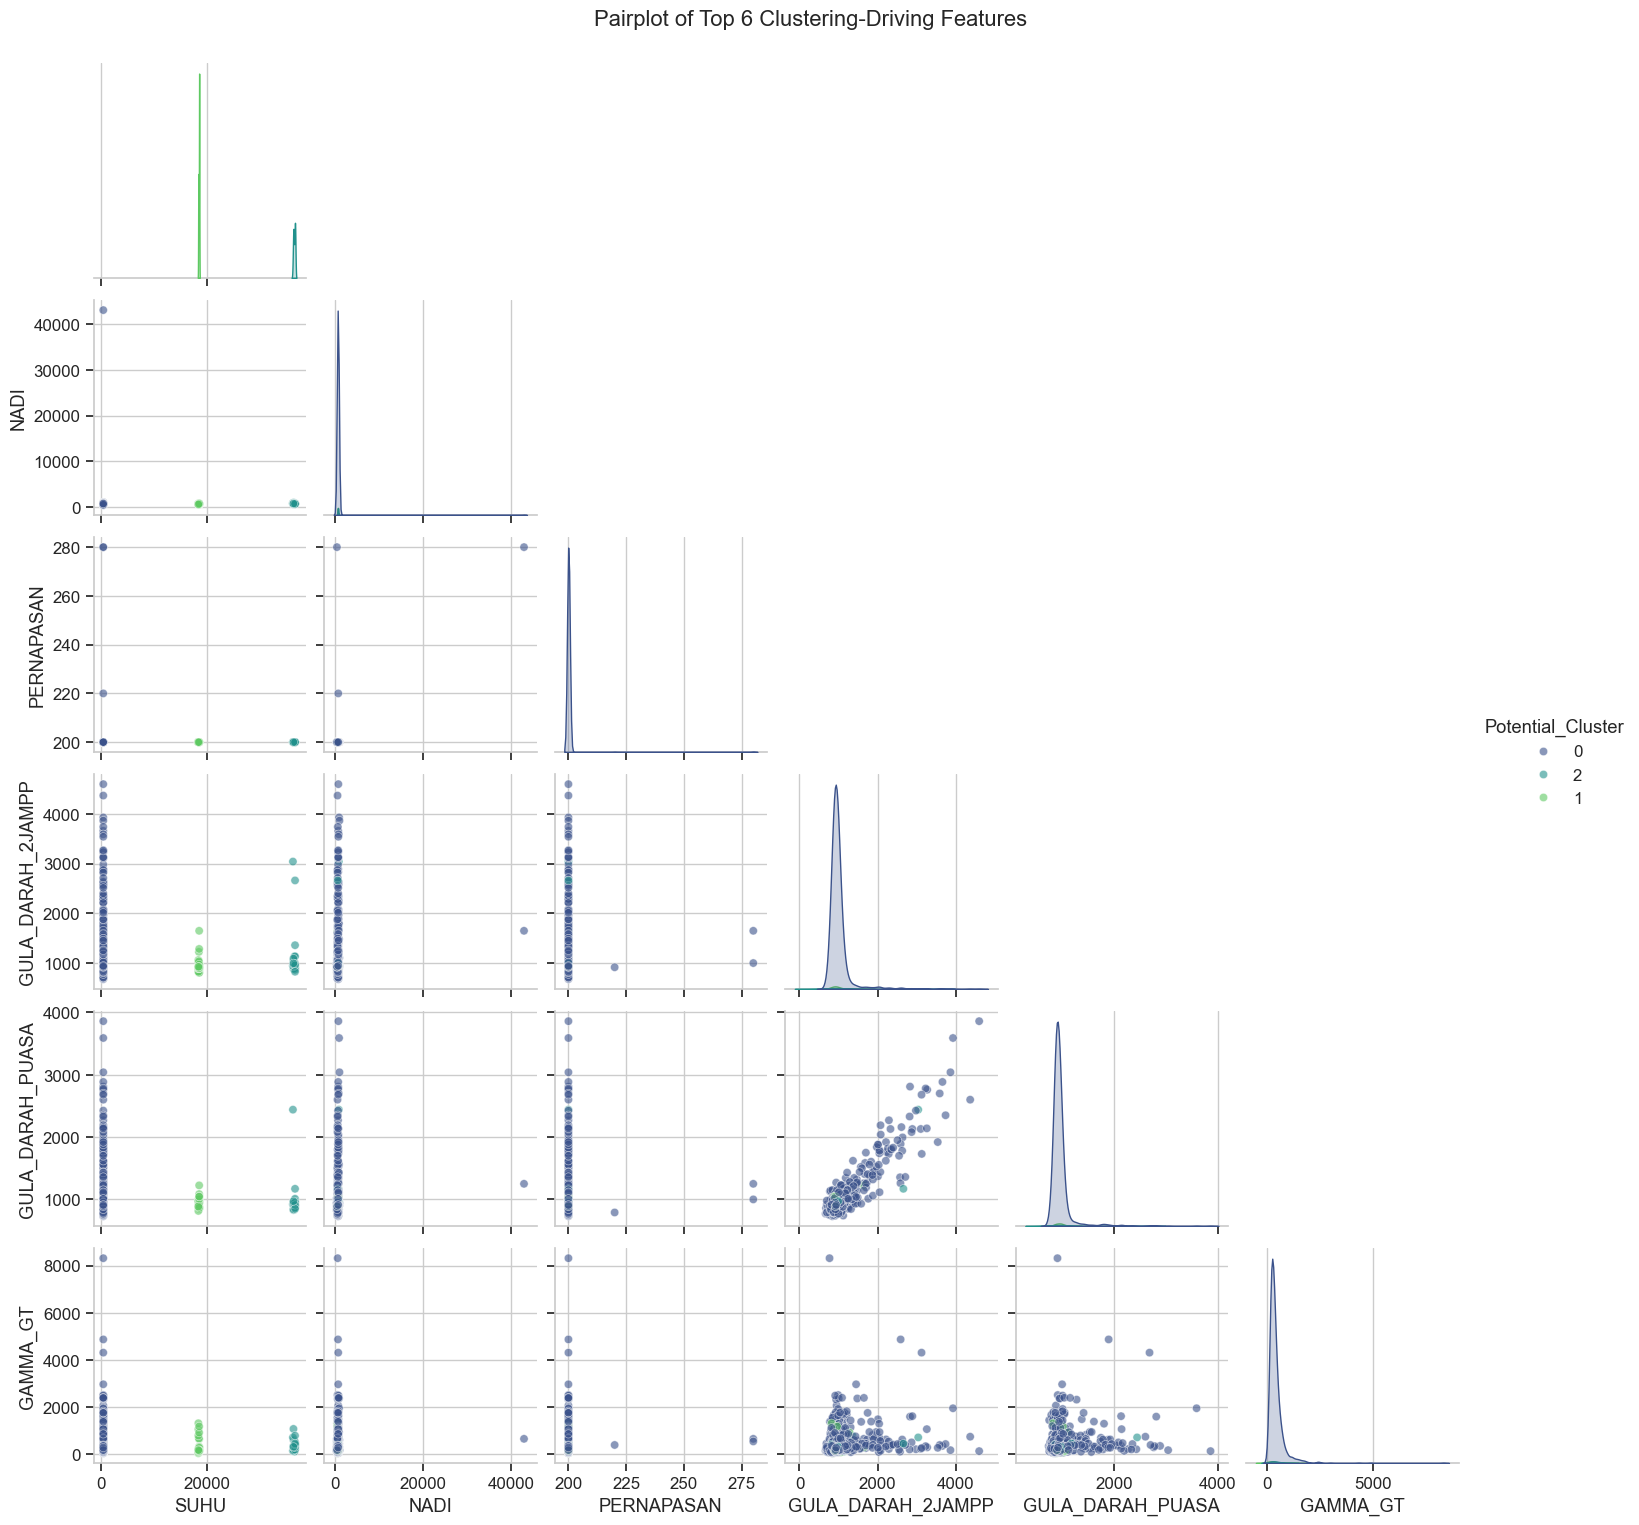


--- IV. CLUSTERABILITY TESTING ---
🎲 Hopkins Statistic: 0.9992 (Mendekati 0 = Clusterable, 0.5 = Random)


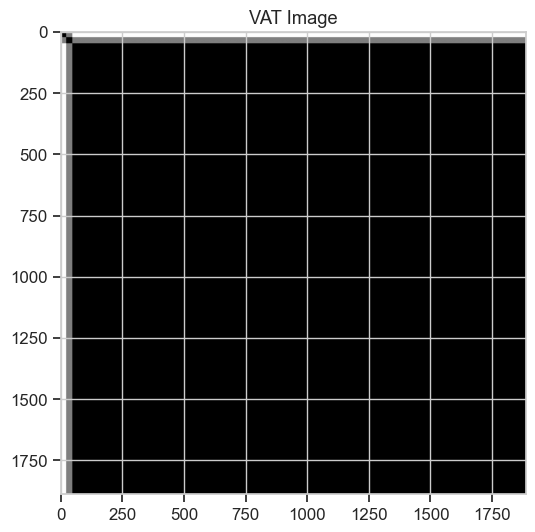


--- V. EXTRA DIMENSIONAL EXPERIMENTS ---

⚙️ Running PCA (n_components=2)
   ➤ Total Explained Variance: 1.0000

⚙️ Running PCA (n_components=3)
   ➤ Total Explained Variance: 1.0000

⚙️ Running UMAP: n_neighbors=50, min_dist=0.3, metric=euclidean

⚙️ Running UMAP: n_neighbors=30, min_dist=0.0, metric=cosine

⚙️ Running UMAP: n_neighbors=10, min_dist=0.0, metric=euclidean

✅ Analisis Lengkap + Extra PCA/UMAP selesai.


In [21]:
# --- CELL 3: EXECUTION ---

# 1. Setup Path
csv_path = "data/Cleaned_agg_pasien_MCU_2.csv"

# 2. Initialize & Run Analysis
analyzer = MCUAnalyzer(csv_path)

if analyzer.load_data():
    # 1. Quality Check
    analyzer.check_data_quality()
    
    # 2. Dimensions (Updated with max_iter where applicable)
    analyzer.analyze_dimensions()
    
    # 3. NEW: Smart Pairplot
    analyzer.analyze_key_features_pairplot(n_top=6) 
    
    # 4. Clusterability
    analyzer.check_clusterability()

    # --- 5. NEW: Helper PCA / UMAP Experiments ---
    print("\n--- V. EXTRA DIMENSIONAL EXPERIMENTS ---")

    # PCA 2D default
    pca_default = analyzer.run_pca(n_components=2)

    # PCA 3D version (if needed)
    pca_3d = analyzer.run_pca(n_components=3)

    # UMAP alternative 1: high neighbors (global structure)
    umap_global = analyzer.run_umap(
        n_neighbors=50,
        min_dist=0.3,
        metric='euclidean',
        n_components=2,
        n_epochs=600
    )

    # UMAP alternative 2: cosine metric (good for health biometrics)
    umap_cosine = analyzer.run_umap(
        n_neighbors=30,
        min_dist=0.0,
        metric='cosine',
        n_components=2
    )

    # UMAP alternative 3: very local structure
    umap_local = analyzer.run_umap(
        n_neighbors=10,
        min_dist=0.0,
        metric='euclidean'
    )

    print("\n✅ Analisis Lengkap + Extra PCA/UMAP selesai.")


📌 Jumlah fitur numerik: 53

📌 Skewness Awal (sort desc):
 NADI                           43.066804
PERNAPASAN                     29.532957
HAEMORROID                      9.565886
ALERGI                          8.031840
GAMMA_GT                        7.572422
SUHU                            7.166099
TENSI_0                         6.101939
GULA_DARAH_PUASA                6.074700
GULA_DARAH_2JAMPP               5.391447
BASOPIL                         5.300713
LEUKOSIT                        5.039960
ALKALINE_PHOSPAT                4.897118
SGOT                            4.036719
SGPT                            3.766947
EPIDIDYMIS_TESTIS_PROSTAT_0     3.543486
TRIGLISERIDA                    3.210566
REFLEK_CAHAYA_1                 3.208452
KERONGKONGAN_0                  3.194214
HIDUNG_0                        3.194214
TELINGA_0                       3.180111
TENSI_1                         2.499818
BILIRUBIN_INDIRECT              1.837369
BILIRUBIN_TOTAL                 1.768825

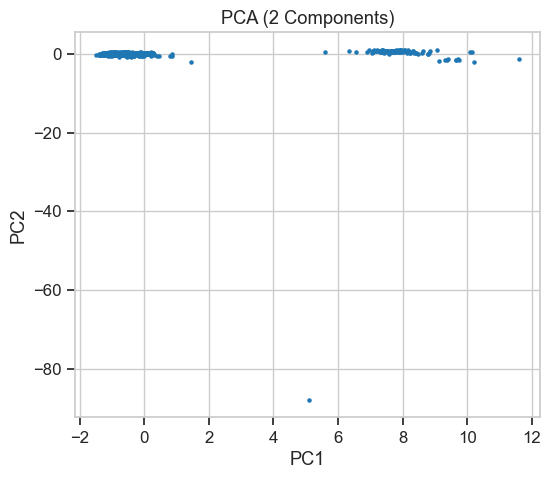

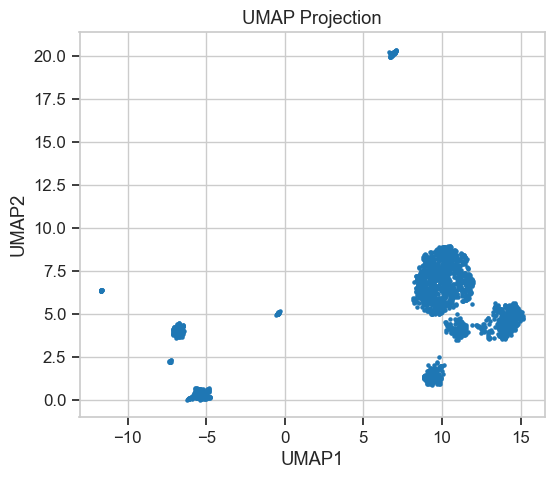

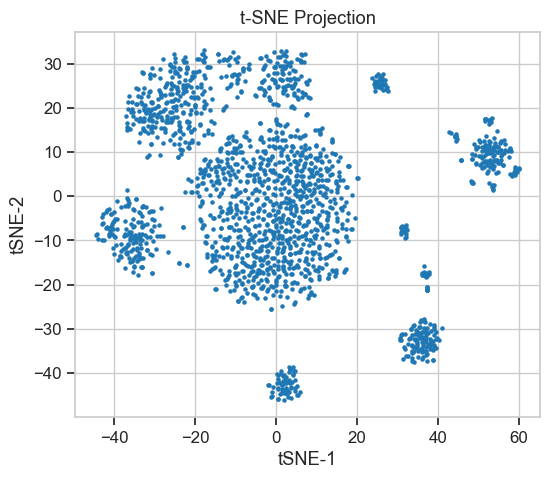


🎯 Selesai: Preprocessing + PCA + UMAP + t-SNE tanpa menentukan K.


In [23]:
# --- CELL BARU: PREPROCESS + PCA + UMAP + t-SNE (NO CLUSTERING) ---

# -------------------------------------------------------
# 1. LOAD CLEANED DATA
# -------------------------------------------------------
 # pastikan analyzer sudah load data di cell sebelumnya


df = analyzer.df.copy()   # pastikan analyzer sudah load data di cell sebelumnya
# Ambil fitur numerik saja
num_df = df.select_dtypes(include=[np.number]).copy()
print("📌 Jumlah fitur numerik:", num_df.shape[1])

# -------------------------------------------------------
# 2. CEK SKEWNESS
# -------------------------------------------------------
skewness = num_df.skew()
print("\n📌 Skewness Awal (sort desc):\n", skewness.sort_values(ascending=False))

# -------------------------------------------------------
# 3. YEO-JOHNSON TRANSFORMATION
# -------------------------------------------------------
pt = PowerTransformer(method='yeo-johnson')
num_transformed = pt.fit_transform(num_df)

print("\n✔ Yeo-Johnson transformation applied.")

# -------------------------------------------------------
# 4. ROBUST SCALER
# -------------------------------------------------------
scaler = RobustScaler()
num_scaled = scaler.fit_transform(num_transformed)

print("✔ RobustScaler applied.")

# -------------------------------------------------------
# 5. PCA (tanpa menentukan jumlah cluster)
# -------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(num_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=5)
plt.title("PCA (2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# -------------------------------------------------------
# 6. UMAP
# -------------------------------------------------------
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
X_umap = umap_model.fit_transform(num_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_umap[:,0], X_umap[:,1], s=5)
plt.title("UMAP Projection")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.grid(True)
plt.show()

# -------------------------------------------------------
# 7. t-SNE
# -------------------------------------------------------
tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    random_state=42
)
X_tsne = tsne_model.fit_transform(num_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], s=5)
plt.title("t-SNE Projection")
plt.xlabel("tSNE-1")
plt.ylabel("tSNE-2")
plt.grid(True)
plt.show()

print("\n🎯 Selesai: Preprocessing + PCA + UMAP + t-SNE tanpa menentukan K.")
